# Spring of Code - Artificial Intelligence
## Week 07: Advanced Machine Learning Models

### Day 05: Decision Trees and Random Forests

In this notebook, we will explore **Decision Trees** and **Random Forests** using Python's Scikit-Learn library.


Oxford Primary Science and Mathematics Book

In [1]:
from sklearn.datasets import load_iris


iris = load_iris(as_frame=True)
X_iris = iris.data.values
y_iris = iris.target.values
print(f"Features shape: {X_iris.shape}")
print(f"Target shape: {y_iris.shape}")

Features shape: (150, 4)
Target shape: (150,)


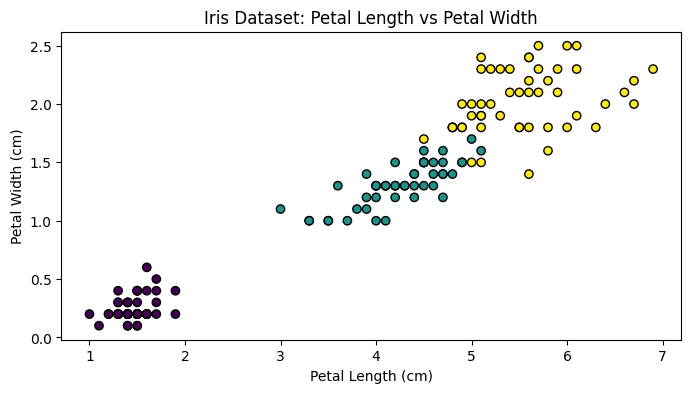

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))

plt.scatter(
    iris.frame['petal length (cm)'],
    iris.frame['petal width (cm)'],
    c=iris.target,
    cmap='viridis',
    edgecolor='k',
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Dataset: Petal Length vs Petal Width")
plt.show()

# Decision Trees
A decision tree is a flowchart-like structure where each internal node represents a "test" on an attribute, each branch represents the outcome of the test, and each leaf node represents a class label (decision taken after computing all attributes).

<img src="decision_tree.png" alt="Decision Tree" width="600">

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)


## Decision Tree Classification


In [16]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(max_depth=100, max_leaf_nodes=100)
tree_clf.fit(X_train[:, 2:], y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,100
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,100
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
tree_clf.score(X_test[:, 2:], y_test)

1.0

c:\Users\asadu\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "
C:\Users\asadu\AppData\Local\Temp\ipykernel_8808\3755504584.py:20: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 3
  plt.legend(handles=plt.scatter([], [], c='#FFAAAA', label='Setosa').legend_elements()[0] +


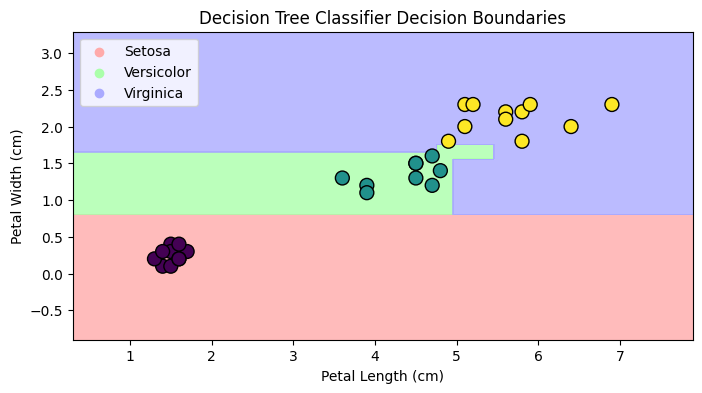

In [18]:
pred = tree_clf.predict(X_test[:, 2:])

# Visualize the results with decision boundaries
import numpy as np
from matplotlib.colors import ListedColormap

# Create a mesh grid for plotting decision boundaries
x_min, x_max = X_test[:, 2].min() - 1, X_test[:, 2].max() + 1
y_min, y_max = X_test[:, 3].min() - 1, X_test[:, 3].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8, 4))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
plt.contourf(xx, yy, Z, alpha=0.8, cmap=cmap_light)
plt.scatter(X_test[:, 2], X_test[:, 3], c=y_test, edgecolor='k', marker='o', s=100, cmap='viridis')
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Decision Tree Classifier Decision Boundaries")
plt.legend(handles=plt.scatter([], [], c='#FFAAAA', label='Setosa').legend_elements()[0] +
           plt.scatter([], [], c='#AAFFAA', label='Versicolor').legend_elements()[0] +
           plt.scatter([], [], c='#AAAAFF', label='Virginica').legend_elements()[0], labels=['Setosa', 'Versicolor', 'Virginica'])
plt.show()

## Making Predictions

<img src="decision_tree_prediction.png" alt="Decision Tree Prediction" width="800">

In [19]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

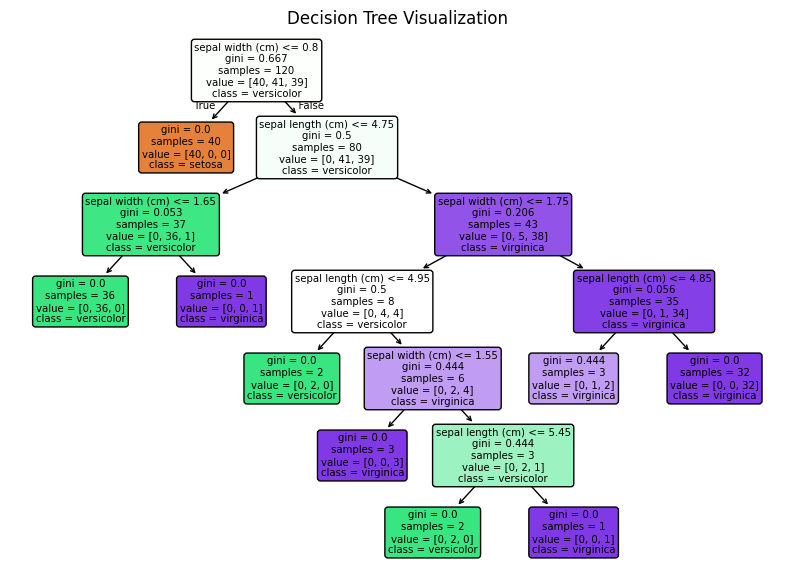

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7))
plot_tree(tree_clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

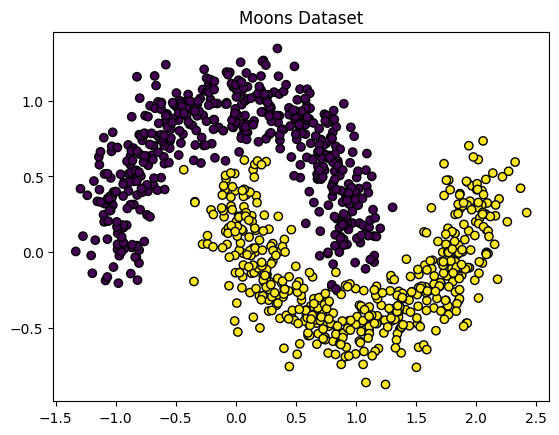

In [28]:
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(n_samples=1000, noise=0.15, random_state=42)

X_moon.shape, y_moon.shape
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='viridis', edgecolor='k')
plt.title("Moons Dataset")
plt.show()

In [29]:
from sklearn.model_selection import train_test_split

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_moon, y_moon, test_size=0.3, random_state=42
)


In [31]:

tree_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
tree_clf.score(X_train, y_train)

0.9128571428571428

In [34]:
tree_clf.score(X_test, y_test)

0.93

c:\Users\asadu\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "
C:\Users\asadu\AppData\Local\Temp\ipykernel_8808\1719699167.py:17: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 2
  plt.legend(handles=plt.scatter([], [], c='#FFAAAA', label='Class 0').legend_elements()[0] +


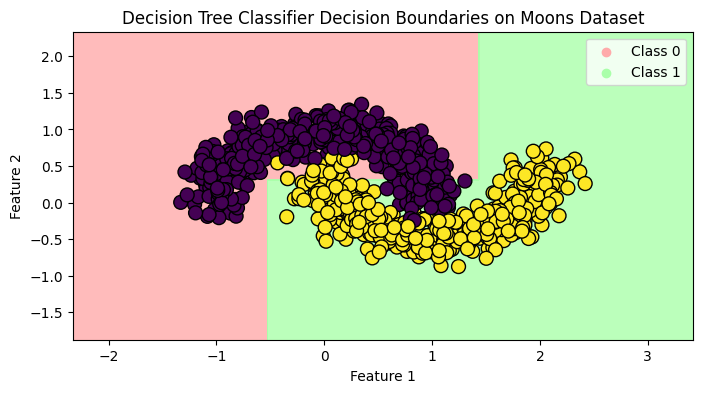

In [32]:
# Visualize the decision boundaries for the moons dataset
import numpy as np
from matplotlib.colors import ListedColormap
# Create a mesh grid for plotting decision boundaries
x_min, x_max = X_moon[:, 0].min() - 1, X_moon[:, 0].max() + 1
y_min, y_max = X_moon[:, 1].min() - 1, X_moon[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8, 4))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
plt.contourf(xx, yy, Z, alpha=0.8, cmap=cmap_light)
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, edgecolor='k', marker='o', s=100, cmap='viridis')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Tree Classifier Decision Boundaries on Moons Dataset")
plt.legend(handles=plt.scatter([], [], c='#FFAAAA', label='Class 0').legend_elements()[0] +
           plt.scatter([], [], c='#AAFFAA', label='Class 1').legend_elements()[0], labels=['Class 0', 'Class 1'])
plt.show()

In [35]:
import pandas as pd

df = pd.read_csv(r'D:\NAVTTC-AI-Course\datasets\Social_Network_Ads.csv')

df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [48]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [51]:
X = df.iloc[:,:2].values
y = df['Purchased'].values

X.shape

(400, 2)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)



(320, 2)

In [60]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [62]:
clf.score(X_test, y_test)

0.8875

In [ ]:
from sklearn.metrics import classification_report
preds = clf.predict(X_test)
a =  classification_report(preds, y_test)
print(a)

              precision    recall  f1-score   support

           0       0.92      0.90      0.91        50
           1       0.84      0.87      0.85        30

    accuracy                           0.89        80
   macro avg       0.88      0.88      0.88        80
weighted avg       0.89      0.89      0.89        80



[Text(0.4502551020408163, 0.9615384615384616, 'x[0] <= 42.5\ngini = 0.455\nsamples = 320\nvalue = [208, 112]'),
 Text(0.2653061224489796, 0.8846153846153846, 'x[1] <= 90500.0\ngini = 0.273\nsamples = 227\nvalue = [190, 37]'),
 Text(0.357780612244898, 0.9230769230769231, 'True  '),
 Text(0.14285714285714285, 0.8076923076923077, 'x[0] <= 36.5\ngini = 0.07\nsamples = 192\nvalue = [185, 7]'),
 Text(0.12244897959183673, 0.7307692307692307, 'gini = 0.0\nsamples = 128\nvalue = [128, 0]'),
 Text(0.16326530612244897, 0.7307692307692307, 'x[1] <= 77500.0\ngini = 0.195\nsamples = 64\nvalue = [57, 7]'),
 Text(0.061224489795918366, 0.6538461538461539, 'x[1] <= 67500.0\ngini = 0.107\nsamples = 53\nvalue = [50, 3]'),
 Text(0.04081632653061224, 0.5769230769230769, 'gini = 0.0\nsamples = 32\nvalue = [32, 0]'),
 Text(0.08163265306122448, 0.5769230769230769, 'x[1] <= 70500.0\ngini = 0.245\nsamples = 21\nvalue = [18, 3]'),
 Text(0.04081632653061224, 0.5, 'x[0] <= 39.5\ngini = 0.5\nsamples = 2\nvalue = [1,

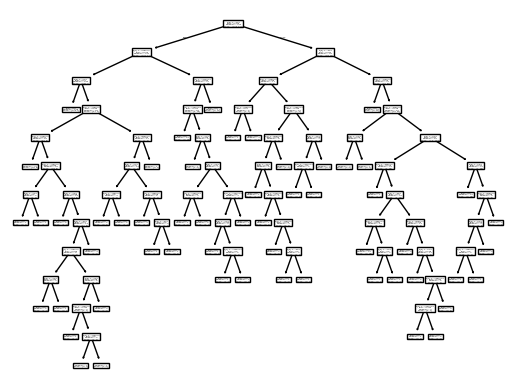

In [61]:
plot_tree(
    clf,
)

In [58]:
# Visualize the decision boundaries for the moons dataset
import numpy as np
from matplotlib.colors import ListedColormap
# Create a mesh grid for plotting decision boundaries
x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8, 4))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
plt.contourf(xx, yy, Z, alpha=0.8, cmap=cmap_light)
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, edgecolor='k', marker='o', s=100, cmap='viridis')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Tree Classifier Decision Boundaries on Moons Dataset")
plt.legend(handles=plt.scatter([], [], c='#FFAAAA', label='Class 0').legend_elements()[0] +
           plt.scatter([], [], c='#AAFFAA', label='Class 1').legend_elements()[0], labels=['Class 0', 'Class 1'])
plt.show()

MemoryError: Unable to allocate 439. GiB for an array with shape (13400200, 4400) and data type float64

## Decision Tree Regression

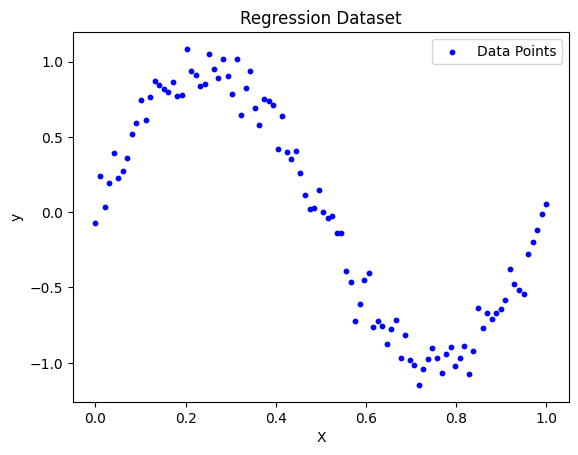

In [66]:
import numpy as np


X_reg = np.linspace(0, 1, 100).reshape(-1, 1)
y_reg = np.sin(2 * np.pi * X_reg).ravel() + np.random.normal(0, 0.1, X_reg.shape[0])

plt.scatter(X_reg, y_reg, color='blue', s=10, label='Data Points')
plt.title("Regression Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [67]:
from sklearn.tree import DecisionTreeRegressor

reg_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
reg_tree.fit(X_reg, y_reg)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


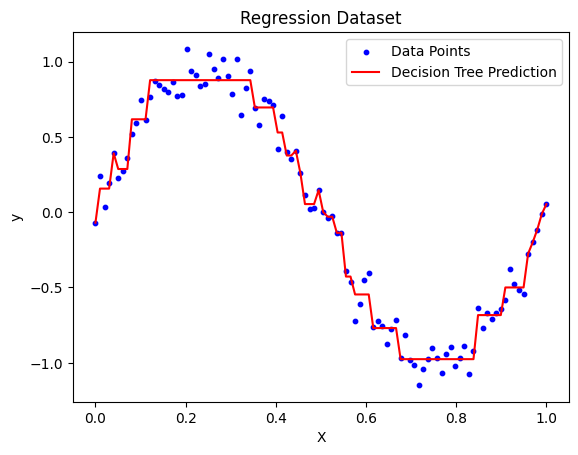

In [68]:
y_pred = reg_tree.predict(X_reg)

plt.scatter(X_reg, y_reg, color="blue", s=10, label="Data Points")
plt.plot(X_reg, y_pred, color="red", label="Decision Tree Prediction")
plt.title("Regression Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [69]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_reg, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 0.0057


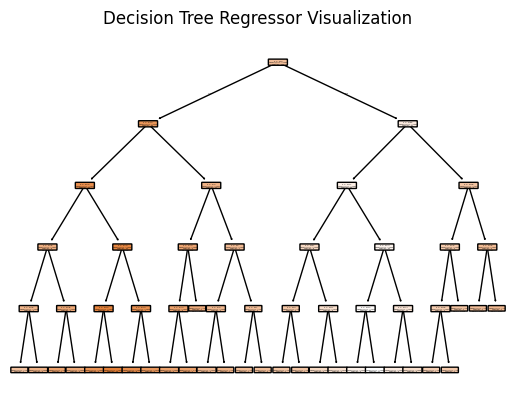

In [70]:
plot_tree(reg_tree,
            feature_names=["X"],
            filled=True,
            rounded=True)
plt.title("Decision Tree Regressor Visualization")
plt.show()

# Ensemble Learning
It is a technique that combines multiple machine learning models to improve overall performance. The main idea is to leverage the strengths of individual models while mitigating their weaknesses.

## Voting Classifier
A voting classifier combines multiple classification models and predicts the class label based on the majority vote (for classification) or average prediction (for regression).

<img src="voting_classifiers.png" alt="Voting Classifier" width="600">


In [71]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
        ('lr', LogisticRegression(max_iter=200, random_state=42)),
        ('svc', SVC(probability=True, random_state=42))
    ], voting='hard'
)

voting_clf.fit(X_train, y_train)

,estimators,"[('dt', ...), ('lr', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1


In [72]:
voting_clf.estimators_

[DecisionTreeClassifier(max_depth=3, random_state=42),
 LogisticRegression(max_iter=200, random_state=42),
 SVC(probability=True, random_state=42)]

In [73]:
voting_clf.named_estimators_

{'dt': DecisionTreeClassifier(max_depth=3, random_state=42),
 'lr': LogisticRegression(max_iter=200, random_state=42),
 'svc': SVC(probability=True, random_state=42)}

In [74]:
for model in voting_clf.estimators_:
    print(type(model))

<class 'sklearn.tree._classes.DecisionTreeClassifier'>
<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.svm._classes.SVC'>


In [75]:
for name, model in voting_clf.named_estimators_.items():
    accuracy = model.score(X_test, y_test)
    print(f"{name} accuracy: {accuracy}")

dt accuracy: 0.9
lr accuracy: 0.825
svc accuracy: 0.725


In [76]:
voting_clf.score(X_test, y_test)

0.8125

## Bagging and Pasting
Bagging (Bootstrap Aggregating) and Pasting are ensemble techniques that involve training multiple instances of the same model on different subsets of the training data.
- Bagging: Samples are drawn with replacement.
- Pasting: Samples are drawn without replacement.

### Random Forests
A Random Forest is an ensemble of decision trees, typically trained with the bagging method. The general idea is to combine multiple decision trees to improve the overall model's accuracy and robustness.

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)  # random forest of 100 trees
rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
rf_clf.score(X_test, y_test)

0.95